##### Instructions
- Keep the original structure, you may add additional code cells and/or mark-down cells for clarity, legibility and/or structure.
- Add the required descriptions, explanations, justifications to the mark-down cells.

# EXAM03: Data Science Group Assignment - Iteration 3

**Group name:** Need Help

**Student names & numbers:**
* [Xue Hu] - [100193]
* [Roos Hogervorst] - [101484]
* [Sas van Damme] - [101990]

---

## 0. Iteration setup

**Import libraries**

In [43]:
# CODE CELL: Import the necessary libraries for this iteration (including scikit-learn models and metrics)
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

**Load & Merge dataset(s)**

In [44]:
# CODE CELL: Import the necessary datasets for this iteration.
# Load your fully cleaned dataset from Iteration 2 AND the new performance logs.
# Merge them together based on the Ship_ID
df_performance = pd.read_csv("./data/ship_performance_logs_iter3.csv")
df_inventory_inspections = pd.read_csv("./data/ships_merged.csv")

df = df_inventory_inspections.merge(df_performance, on="Ship_ID", how="left")

---

## 1. Business Understanding

**Situation description**

*Describe the final problem. Why is Nebula Brokerage moving from the simple models (iterations 1 and 2) to a machine learning approach?*

Nebula Brokerage is moving to a machine learning approach because our previous models have reached their limit. In iteration 1 we used the median baseline, and in iteration 2 we used the manual if/else rules. But that won't be sufficient enough anymore, for mainly 2 reasons. 

First, pricing leakage: Our previous models ignored usage. A ship might be relatively new by age (Model_Cycle) but have extremely high mileage (Lightyears_Traveled), leading us to overprice worn-out vessels.

Secondly, hidden safety risks: Manual rules cannot easily capture the complex relationships between mechanical data and legal history. By ignoring the imperial registry (Registration_Status), we were missing stolen or smuggler ships that represent a legal and mechanical liability. So, we need algorithms that can see patterns a human might miss. 

**Business objective(s)**

*Justify why an AI-driven pipeline (predicting both Galactic Credits and Condition) adds business value.*

So, the objective is to deploy an AI-driven pipeline to modernize operations. For pricing, we aim to recapture millions in leaked credits by pricing ships based on their actual mileage, ensuring we don't underprice high-performance ships or overprice worn-out ships. For safety, we aim to automate safety compliance using a decision tree that incorporates legal status. This adds business value by protecting the company from selling defective ships and ensuring compliance with trade laws.

**Data mining goal(s)**

*Explain the two modeling tasks for this iteration.*

Regression: training a linear regression model to quantify the exact impact of Lightyears_Traveled on Galactic_Credits

Classification: Training a decision tree classifier to replace our manual rules and predict Hull_Integrity more accurately by incorporating the new Registration_Status feature.


**Success criteria**

*Determine the success criteria.*

Our success criteria are based on 3 targets. 
1. Pricing success: The linear regressions must achieve an MAE lower than 10,000 credits, beating our iteration 1 baseline of 10,652.
2. Safety success: The decision tree must achieve an accuracy > 85% and a recall for 'critical' ships > 90%, outperforming our manual iteration 2 model, which reached 79% accuracy.
3. Actionable insight: The regression model must clearly identify the price-per-lightyear depreciation rate to inform future trade negotiations. 

---

## 2. Data Understanding

**Data exploration (New Features)**

*Show the summary statistics for the newly merged data. Focus your description on the new variables: Lightyears_Traveled and Registration_Status.*

In [45]:
# CODE CELL: Show basic statistics and information for the final merged dataset
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 355071 entries, 0 to 355070
Data columns (total 12 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Ship_ID                   355071 non-null  int64  
 1   Galactic_Credits          355071 non-null  int64  
 2   Model_Cycle               355071 non-null  float64
 3   Ship_Manufacturer         355071 non-null  str    
 4   Sector                    355071 non-null  str    
 5   Hull_Integrity            355071 non-null  str    
 6   Reactor_Power             355071 non-null  float64
 7   Propulsion_Type           355071 non-null  str    
 8   Ship_Class                355071 non-null  str    
 9   Predicted_Hull_Integrity  355071 non-null  str    
 10  Lightyears_Traveled       351651 non-null  float64
 11  Registration_Status       351651 non-null  str    
dtypes: float64(3), int64(2), str(7)
memory usage: 32.5 MB


,Ship_ID,Galactic_Credits,Model_Cycle,Reactor_Power,Lightyears_Traveled
count,3.550710e+05,355071.000000,355071.000000,355071.000000,351651.000000
mean,7.311481e+09,18676.428799,7511.248353,68.929651,105.027135
std,4.382615e+06,13250.473090,8.956381,38.278429,88.960987
min,7.301583e+09,501.000000,7400.000000,30.000000,0.000000
25%,7.308096e+09,7900.000000,7508.000000,40.000000,30.743526
50%,7.312595e+09,15800.000000,7513.000000,60.000000,85.750730
75%,7.315242e+09,27500.000000,7517.000000,80.000000,157.834571
max,7.317101e+09,68788.000000,7522.000000,240.000000,1559.606111


**Visualizations and patterns**
*Create visualizations to discover the impact of the new features.

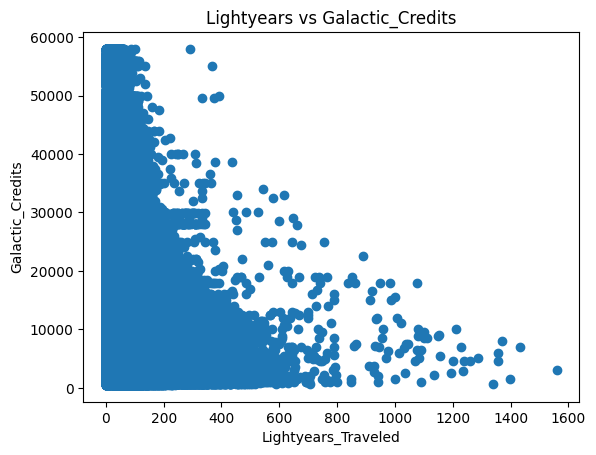

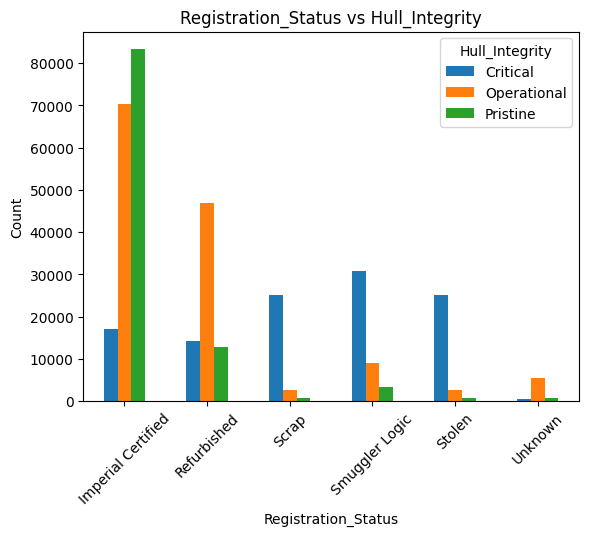

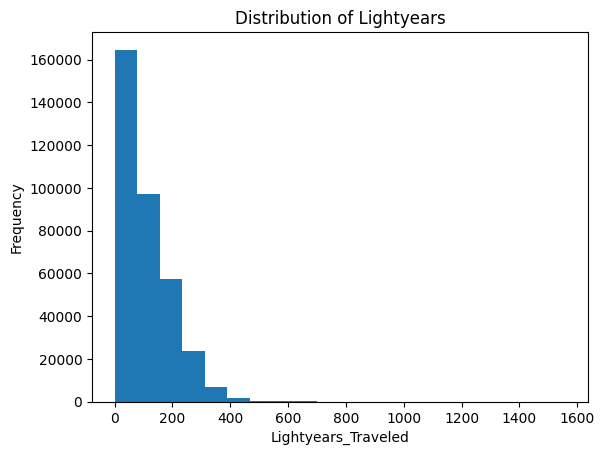

In [46]:
# CODE CELL: Generate visualizations for the new features

# Scatter plot of Lightyears_Traveled vs Galactic_Credits
plt.scatter(df["Lightyears_Traveled"], df["Galactic_Credits"])
plt.xlabel("Lightyears_Traveled")
plt.ylabel("Galactic_Credits")
plt.title("Lightyears vs Galactic_Credits")
plt.show()

# Bar plot of Engine_Efficiency by Registration_Status
pd.crosstab(df["Registration_Status"], df["Hull_Integrity"]).plot(kind="bar")
plt.xlabel("Registration_Status")
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.title("Registration_Status vs Hull_Integrity")
plt.show()

# Histogram of Lightyears_Traveled
plt.hist(df["Lightyears_Traveled"], bins=20)
plt.xlabel("Lightyears_Traveled")
plt.ylabel("Frequency")
plt.title("Distribution of Lightyears")
plt.show()


**Data insights and data quality**

* **Insights:** Does high mileage lower the price? Does a 'Stolen' status correlate with critical hull condition?
* **Quality issues:** Document any missing values and other issues

**Insights:**
1. Higher mileage leads to lower prices, indicating that usage is a key factor in price determination.
2. ships with “Stolen”, “Smuggler Logic” or "Scrap" status have a much higher proportion of Critical conditions, while “Imperial Certified” ships are mostly in better condition.

**Quality issues:**
1. Lightyears_Traveled and Registration_Status contain missing values and should be checked and handled.
2. Most ships have low mileage, while a few have extremely high mileage, indicating a right-skewed distribution with potential outliers.

---

## 3. Data Preparation

**Cleaning and preprocessing**

*Describe and justify how you resolve your data errors.*

In [47]:
# CODE CELL: Data cleaning, preprocessing
df.duplicated().sum()

# check possible typos in categorical columns
print(df["Registration_Status"].unique())

# fill missing values in Lightyears_Traveled with median
df["Lightyears_Traveled"] = df["Lightyears_Traveled"].fillna(df["Lightyears_Traveled"].median())

missing_data = df[df['Registration_Status'].isnull()]
print(missing_data['Hull_Integrity'].value_counts())

# fill missing values in Registration_Status with "Missing"
df["Registration_Status"] = df["Registration_Status"].fillna("Missing")

# check for outliers in Lightyears_Traveled using IQR method
Q1 = df["Lightyears_Traveled"].quantile(0.25)
Q3 = df["Lightyears_Traveled"].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
outliers = df[df["Lightyears_Traveled"] > upper_bound]
print("Outliers in Hull_Integrity:", outliers["Hull_Integrity"].value_counts())

df.info()
df.describe()

<StringArray>
[    'Smuggler Logic', 'Imperial Certified',            'Unknown',
                  nan,        'Refurbished',             'Stolen',
              'Scrap']
Length: 7, dtype: str
Hull_Integrity
Pristine       2290
Operational     853
Critical        277
Name: count, dtype: int64
Outliers in Hull_Integrity: Hull_Integrity
Critical       4416
Operational     344
Pristine         55
Name: count, dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 355071 entries, 0 to 355070
Data columns (total 12 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Ship_ID                   355071 non-null  int64  
 1   Galactic_Credits          355071 non-null  int64  
 2   Model_Cycle               355071 non-null  float64
 3   Ship_Manufacturer         355071 non-null  str    
 4   Sector                    355071 non-null  str    
 5   Hull_Integrity            355071 non-null  str    
 6   Reactor_Power           

,Ship_ID,Galactic_Credits,Model_Cycle,Reactor_Power,Lightyears_Traveled
count,3.550710e+05,355071.000000,355071.000000,355071.000000,355071.000000
mean,7.311481e+09,18676.428799,7511.248353,68.929651,104.841467
std,4.382615e+06,13250.473090,8.956381,38.278429,88.551535
min,7.301583e+09,501.000000,7400.000000,30.000000,0.000000
25%,7.308096e+09,7900.000000,7508.000000,40.000000,31.119467
50%,7.312595e+09,15800.000000,7513.000000,60.000000,85.750730
75%,7.315242e+09,27500.000000,7517.000000,80.000000,156.981369
max,7.317101e+09,68788.000000,7522.000000,240.000000,1559.606111


**Explanation:**
1. Missing values in Lightyears_Traveled were filled using the median. This variable is right-skewed and contains extreme values, so the median provides a more robust estimate than the mean.

2. Missing values in Registration_Status were labeled as "Missing" because they are not randomly distributed (mostly associated with Pristine ships, possibly newly produced and not yet registered); assigning them to an existing category such as "Unknown", which already shows a different pattern (mainly Operational), would mix distinct meanings and distort relationships, while imputing values based on Hull_Integrity would mean using the answer (the target) to guess the input, which would create artificial patterns and make the model unreliable.

3. Outliers in Lightyears_Traveled were identified using the IQR method. Most of these observations are associated with Critical hull conditions, suggesting that they likely represent Pristine ships rather than data errors. Therefore, they were retained as valid extreme cases.

**Feature encoding**

*Describe how you converted your categorical columns into a format the model can use.*

In [48]:
# CODE CELL: Apply feature ecoding and define your features (X)
y_reg = df["Galactic_Credits"]
y_clf = df["Hull_Integrity"]

X = df.drop(["Galactic_Credits", "Hull_Integrity"], axis=1)

X_encoded = pd.get_dummies(X, drop_first=True)

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_encoded, y_reg, test_size=0.2, random_state=42
)

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_encoded, y_clf, test_size=0.2, random_state=42
)

**Explanation:**

To prepare the data for modeling, all categorical columns were converted into numerical format using one-hot encoding. This ensures that the machine learning models can interpret categorical features correctly.

Using drop_first=True to avoid multicollinearity by removing the first category of each feature.

The dataset was split into training and testing sets for both regression (Galactic_Credits) and classification (Hull_Integrity) tasks using an 80/20 split.

---

## 4. Modeling: Task A

**Regression setup**

*Set up a [Linear Regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) model to predict `Galactic_Credits`. Make sure to split your data into training and testing sets.*

In [49]:
# CODE CELL: Train-Test split & train the Linear Regression model

# Part 4: Train Linear Regression
model_reg = LinearRegression()
model_reg.fit(X_train_reg, y_train_reg)

# Print the Odometer Impact (Coefficient)
mileage_col_index = list(X_encoded.columns).index('Lightyears_Traveled')
mileage_coef = model_reg.coef_[mileage_col_index]

print(f"Regression R2 Score on Train: {model_reg.score(X_train_reg, y_train_reg):.4f}")
print(f"For every 1 Lightyear traveled, the price drops by: {abs(mileage_coef):.2f} credits.")

Regression R2 Score on Train: 0.7675
For every 1 Lightyear traveled, the price drops by: 46.76 credits.


**Testing and performance (Regression)**

*Calculate the MAE, RMSE and R2 score. Create a plot showing Actual vs. Predicted prices to visually verify model performance.*

MAE: 4663.72
RMSE: 6358.64
R2 Score: 0.7696


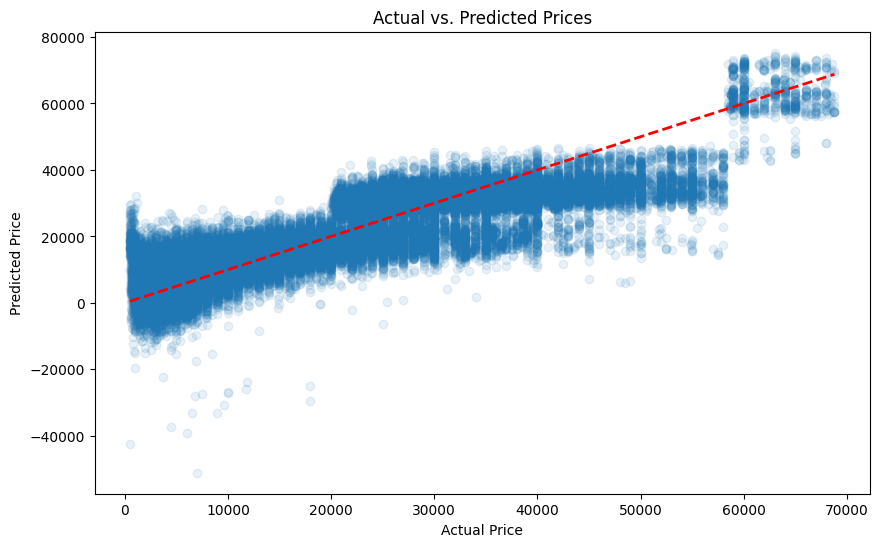

In [50]:
# CODE CELL: Evaluate the rgression model and plot Actual vs Predicted

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Predictions
y_pred_reg = model_reg.predict(X_test_reg)

# Metrics
mae_reg = mean_absolute_error(y_test_reg, y_pred_reg)
rmse_reg = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
r2_reg = r2_score(y_test_reg, y_pred_reg)

print(f"MAE: {mae_reg:.2f}")
print(f"RMSE: {rmse_reg:.2f}")
print(f"R2 Score: {r2_reg:.4f}")

# Visualization
plt.figure(figsize=(10, 6))
plt.scatter(y_test_reg, y_pred_reg, alpha=0.1)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs. Predicted Prices")
plt.show()

**Regression Analysis & Insights**

Our Linear Regression model successfully addressed the "Pricing Leakage" identified by the board. By incorporating the odometer data, we discovered that usage is a primary driver of depreciation, with ships losing approximately 46.76 credits per lightyear traveled.

**Model Performance:**

 MAE: 4,663.72 – This is a massive improvement over our Iteration 1 baseline of 10,652. Our pricing is now twice as accurate.
 
 R2 Score: 0.7696 – Our features explain ~77% of the price variance.

**Visual Verification:**

The "Actual vs. Predicted" plot shows a strong linear correlation, with the majority of points clustered around the identity line (red dashed line). The dense sludge in the 10k–30k range reflects the high volume of standard vessels in the fleet. The horizontal shelf at the top of the plot confirms that our 99th percentile price capping from previous iterations was maintained, preventing extreme outliers from skewing our new AI-driven pricing.

---

## 5. Modeling: Task B

**Classification setup**

*Set up a [Decision Tree Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) to predict `Hull_Integrity`. Split the data into training and testing sets.*

In [51]:
# CODE CELL: Train-Test split & train the Decision Tree model.
#import
from sklearn.tree import DecisionTreeClassifier, plot_tree

#initializing
model_clf = DecisionTreeClassifier(max_depth=8, random_state=42)

#training
model_clf.fit(X_train_clf, y_train_clf)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

**Testing and performance (classification)**

*Calculate the Accuracy and plot a confusion matrix. Explain what the matrix tells you about the predictions.*

Accuracy: 0.8711


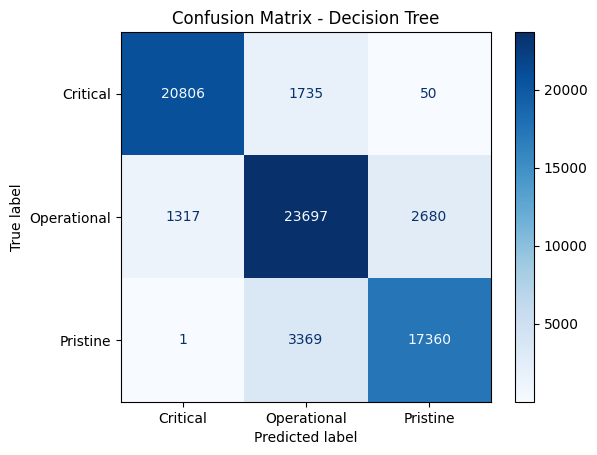

              precision    recall  f1-score   support

    Critical       0.94      0.92      0.93     22591
 Operational       0.82      0.86      0.84     27694
    Pristine       0.86      0.84      0.85     20730

    accuracy                           0.87     71015
   macro avg       0.88      0.87      0.87     71015
weighted avg       0.87      0.87      0.87     71015



In [52]:
# CODE CELL: Evaluate your classification model (check ou tthe metrics, include a confusion matrix)
#importing
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import plot_tree
from sklearn.metrics import classification_report

#predictions
y_pred_clf = model_clf.predict(X_test_clf)

#accuracy
accuracy = accuracy_score(y_test_clf, y_pred_clf)
print(f"Accuracy: {accuracy:.4f}")

#confusion matrix
cm = confusion_matrix(y_test_clf, y_pred_clf, labels=model_clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model_clf.classes_)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Decision Tree")
plt.show()

#prediction report
print(classification_report(y_test_clf, y_pred_clf))

**What the matrix says about the predictions**

Overall this confusion matrix shows that the predicitons are now highly accurate, with an accuracy of 87.11%. Visually, you can tell this by seeing that the diagonal line down the matrix is by far the darkest. This indicates that with this model majority of the labels are being correctly classified.

* The **ciritical** label are the most accurately classfied, making sure that the majority of unsafe ships get detected. However there still remains a portion of critical ships being wrongly classified as operational, which shows the most important remaining risks and room for improvement.

* **Operational** ships are overall correctly detected, but there are still cases where the model is either overly cautious and identifies it as critical or instead overestimates the ship and classifies it as pristine.

* For **prisine** ships the model succeeds in correctly identifying most ships as such, but there is still a portion of pristine ships being incorrectly identified as operational. This goes to show that there is room for improving the distinguishing between high-quality and average vessels.

---

## 6. Evaluation

**Assessment against success criteria** 

*Compare your models to the baselines:*
* *Are thr scores of this regression model better than Iteration 1? Why?*
* *Are the scores of the decision tree better than your manual rules from Iteration 2? Why?*

**Key findings and limitations**

*What are the final conclusions? Should Nebula Brokerage deploy these models? What are the remaining limitations?*

---


**Assessment against success criteria**

*Are the scores of this regression model better than Iteration 1? Why?*

* The iteration 3 regression model definitely outperforms the one from iteration 1. The MAE has gone from 10652.06 credits to 4663.72 credits, cutting errors by more than half. RMSE was also better this time, going from 13585.93 to 6359.64 meaning the model handles extremes prices better now. The improvements here mainly come from adding “Lightyears_Traveled”, which shows how much a ship has been used. The regression now actually caputers the real devaluation, so ship prices are more accurate and fair.

*Are the scores of the decision tree better than your manual rules from Iteration 2? Why?*

* The decision tree we used this time definitely beats the manual rules from iteration 2. Accuracy went from 79% to 87.11%, and recall for critical ships went from 85% to 91%, reducing the chance of missing unsafe ships. The tree uses “Registration_Status” and can see interactions between features like “Lightyears_Traveled”, “Reactor_Power”, and ship class, which is something that the manual rules couldn’t do. This helps the model handle risky ships that might look fine under simple rules.

---

**Key findings and limitations**

*What are the final conclusions?*

* Iteration 3 models fix most of the problems we saw in earlier iteration models. Pricing issues are mostly solved by the regression that uses mileage, and safety checks are better because of the decision tree using legal status and other ship features.
* The regression model gives clear information about how ships lose value: for every lightyear a ship has traveled, it loses 46.76 credits. This can help guide pricing and sales decisions.
* The decision tree makes it much less likely to sell unsafe ships. It helps follow the rules and reduces the chance of legal or mechanical problems.
* Both models can now handle complex patterns and interactions that simple rules or older models could not. This shows that these models can truly help this business.

*Should Nebula Brokerage deploy these models?*

Yes, definitely. These models would help Nebula Brokerage improve profits and reduce many risks. Some examples of these benefits are:
* Pricing is now way more accurate, which prevents losing millions in lost credits.
* Safety predictions are more reliable, which lowers the chance of selling unsafe ships.
* The models can be updated with new ship registry data, so they can continue to work well over time.


*What are the remaining limitations?*

* The decision tree might memorize unusual patterns in the training data, especially for rare hull conditions.
* Some missing or incorrect data (like unregistered or new ships) could still cause small mistakes.
* Things outside the dataset, like ship upgrades, new laws or even market changes are not included in the models.
* Because data changes over time, models must be retrained regularly to keep the accuracy high.

---

Use [pandas' to_csv](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_csv.html) to export your cleaned and merged dataset.

In [53]:
df.to_csv("./data/ships_final_merged.csv", index=False)

---

## 7. Personal Contribution

| Student name | Contribution | Personal lessons learned |
| :--- | :--- | :--- |
| Xue | *Analyzed new features using visualizations to identify relationships , handled data quality issues and prepared the data through one-hot encoding and train-test splitting.* | *Non-random missing data must be handled carefully to avoid bias, and multicollinearity can occur when encoding categorical variables, which should be addressed (e.g. using drop_first) to improve model stability.* |
| Sas | *Defined the Business Understanding and Success Criteria for the AI transition. Implemented and evaluated the Linear Regression model for price optimization.* | *I learned that age is not the only thing that affects a ship's price; the mileage is just as important. By training the linear regression model, I discovered that every lightyear traveled drops a ship's value by about 47 credits. So, ignoring usage was a major financial risk for the company, as we were previously overpricing worn-out ships.* |
| Roos | *Trained and evaluated the Decision Tree model for Hull_Integrity prediction, visualized the tree structure, and analyzed the confusion matrix to interpret model performance and identify misclassifications.* | *I learned how important it is to include legal and categorical data when predicting ship safety. Using the decision tree, I saw that interactions between features like registration status, mileage, and reactor power can strongly influence the model’s decisions, which is something manual rules cannot capture.* |